In [1]:
# ============================================================
# 01B_right_censoring_audit.ipynb
# Reviewer 1 Comment 7 — right-censoring audit
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

RAW_FILE = os.path.join(
    WORK_DIR,
    "Perovskite_database_content_all_data.csv"
)

df = pd.read_csv(RAW_FILE, low_memory=False)

print("Raw database shape:", df.shape)

Raw database shape: (43398, 410)


In [2]:
# ============================================================
# FIND ALL STABILITY / PCE FIELDS RELEVANT TO CENSORING
# ============================================================

candidate_cols = [
    c for c in df.columns
    if (
        "Stability" in c
        and (
            "PCE" in c
            or "time" in c.lower()
            or "T80" in c
            or "exposure" in c.lower()
        )
    )
]

print("Potential censoring-related stability fields:")
for c in candidate_cols:
    print(c)

Potential censoring-related stability fields:
Stability_light_cycling_times
Stability_temperature_cycling_times
Stability_time_total_exposure
Stability_periodic_JV_measurements_time_between_jv
Stability_PCE_initial_value
Stability_PCE_burn_in_observed
Stability_PCE_end_of_experiment
Stability_PCE_T95
Stability_PCE_Ts95
Stability_PCE_T80
Stability_PCE_Ts80
Stability_PCE_Te80
Stability_PCE_Tse80
Stability_PCE_after_1000_h
Stability_lifetime_energy_yield
Stability_flexible_cell_PCE_initial_value
Stability_flexible_cell_PCE_end_of_experiment


In [3]:
# Check specifically expected fields
check_cols = [
    "Stability_PCE_T80",
    "Stability_time_total_exposure",
    "Stability_PCE_end_of_experiment",
    "Stability_PCE_after_1000_h",
    "JV_default_PCE"
]

rows = []

for c in check_cols:
    if c in df.columns:
        rows.append({
            "field": c,
            "non_null": int(df[c].notna().sum()),
            "missing": int(df[c].isna().sum()),
            "dtype": str(df[c].dtype)
        })

field_audit = pd.DataFrame(rows)

display(field_audit)

,field,non_null,missing,dtype
0,Stability_PCE_T80,1839,41559,float64
1,Stability_time_total_exposure,7405,35993,float64
2,Stability_PCE_end_of_experiment,7376,36022,float64
3,Stability_PCE_after_1000_h,1013,42385,float64
4,JV_default_PCE,42396,1002,float64


In [4]:
# ============================================================
# CELL 4 — AUDIT FIELDS NEEDED TO IDENTIFY RIGHT-CENSORING
# ============================================================

censor_fields = [
    "Stability_PCE_initial_value",
    "Stability_PCE_end_of_experiment",
    "Stability_time_total_exposure",
    "Stability_PCE_T80",
    "Stability_protocol",
    "Ref_DOI_number",
    "Ref_publication_date"
]

rows = []

for c in censor_fields:
    if c in df.columns:
        rows.append({
            "field": c,
            "non_null": int(df[c].notna().sum()),
            "missing": int(df[c].isna().sum()),
            "dtype": str(df[c].dtype)
        })

censor_field_audit = pd.DataFrame(rows)

display(censor_field_audit)

,field,non_null,missing,dtype
0,Stability_PCE_initial_value,3047,40351,float64
1,Stability_PCE_end_of_experiment,7376,36022,float64
2,Stability_time_total_exposure,7405,35993,float64
3,Stability_PCE_T80,1839,41559,float64
4,Stability_protocol,7431,35967,str
5,Ref_DOI_number,43112,286,str
6,Ref_publication_date,43398,0,str


In [5]:
# ============================================================
# CELL 5 — IDENTIFY CONSERVATIVE RIGHT-CENSORED T80 CASES
# Correct interpretation: Stability_PCE_end_of_experiment
# is already a retained-PCE percentage
# ============================================================

audit = df.copy()

audit["T80_numeric"] = pd.to_numeric(
    audit["Stability_PCE_T80"],
    errors="coerce"
)

audit["exposure_h"] = pd.to_numeric(
    audit["Stability_time_total_exposure"],
    errors="coerce"
)

audit["end_retention_pct"] = pd.to_numeric(
    audit["Stability_PCE_end_of_experiment"],
    errors="coerce"
)

# First inspect the end-of-experiment field
print("End-of-experiment PCE/retention summary:")
print(audit["end_retention_pct"].describe())

print("\nCounts around the T80 criterion:")
print("End retention >= 80%:",
      int((audit["end_retention_pct"] >= 80).sum()))
print("End retention < 80%:",
      int((audit["end_retention_pct"] < 80).sum()))

# Conservative right-censored case:
# - no observed T80
# - known positive exposure time
# - end-of-experiment retained PCE >= 80%
#
# Therefore T80 was not reached within the reported experiment,
# and the only defensible label is T80 > exposure time.

censored_mask = (
    audit["T80_numeric"].isna()
    & audit["exposure_h"].notna()
    & (audit["exposure_h"] > 0)
    & audit["end_retention_pct"].notna()
    & (audit["end_retention_pct"] >= 80)
)

censored = audit.loc[censored_mask].copy()

print("\n========== RIGHT-CENSORING AUDIT ==========")
print("Conservative right-censored devices:", len(censored))
print("Unique DOI groups:", censored["Ref_DOI_number"].nunique())

print("\nExposure duration summary:")
print(censored["exposure_h"].describe())

print("\nEnd-of-experiment retention (%) summary:")
print(censored["end_retention_pct"].describe())

End-of-experiment PCE/retention summary:
count    7376.000000
mean       67.540336
std        32.769160
min         0.000000
25%        50.000000
50%        78.000000
75%        90.000000
max       780.000000
Name: end_retention_pct, dtype: float64

Counts around the T80 criterion:
End retention >= 80%: 3604
End retention < 80%: 3772

========== RIGHT-CENSORING AUDIT ==========
Conservative right-censored devices: 3129
Unique DOI groups: 1860

Exposure duration summary:
count     3129.000000
mean       890.710663
std       1452.369994
min          0.083000
25%        240.000000
50%        600.000000
75%       1000.000000
max      43800.000000
Name: exposure_h, dtype: float64

End-of-experiment retention (%) summary:
count    3129.000000
mean       92.831205
std        21.318005
min        80.000000
25%        87.000000
50%        91.000000
75%        96.000000
max       780.000000
Name: end_retention_pct, dtype: float64


In [6]:
# ============================================================
# CELL 6 — INSPECT RIGHT-CENSORED CANDIDATES
# ============================================================

display_cols = [
    "Ref_DOI_number",
    "Ref_publication_date",
    "Stability_protocol",
    "Stability_PCE_T80",
    "end_retention_pct",
    "exposure_h",
    "Stability_PCE_after_1000_h"
]

display_cols = [
    c for c in display_cols
    if c in censored.columns
]

display(
    censored[display_cols]
    .sort_values("exposure_h", ascending=False)
    .head(30)
)

,Ref_DOI_number,Ref_publication_date,Stability_protocol,Stability_PCE_T80,end_retention_pct,exposure_h,Stability_PCE_after_1000_h
39431,10.1002/ente.202000513,03/09/2020,ISOS-D-1,NaN,100.00,43800.0,NaN
6071,10.1039/c9tc03359a,14/08/2019,ISOS-D-1,NaN,90.00,24000.0,NaN
6069,10.1039/c9tc03359a,14/08/2019,ISOS-D-1,NaN,90.00,24000.0,NaN
27887,10.1002/solr.201800147,23/08/2018,ISOS-D-1I,NaN,88.70,14640.0,NaN
1525,10.1021/acsenergylett.8b01507,06/11/2018,ISOS-D-1,NaN,98.50,11520.0,NaN
2843,10.1038/ncomms15684,01/06/2017,ISOS-L-1,NaN,115.00,10000.0,120.00000
17015,10.1021/acsaem.9b01692,09/12/2019,ISOS-D-1,NaN,100.00,9840.0,100.00000
17014,10.1021/acsaem.9b01692,09/12/2019,ISOS-D-1,NaN,110.00,9840.0,110.00000
17013,10.1021/acsaem.9b01692,09/12/2019,ISOS-D-1,NaN,90.00,9840.0,110.00000
128,10.1126/science.aan2301,12/07/2017,ISOS-D-1,NaN,93.00,9744.0,NaN


In [7]:
# ============================================================
# CELL 7 — QUALITY CONTROL OF RIGHT-CENSORED CANDIDATES
# ============================================================

base_mask = (
    audit["T80_numeric"].isna()
    & audit["exposure_h"].notna()
    & (audit["exposure_h"] > 0)
    & audit["end_retention_pct"].notna()
)

base = audit.loc[base_mask].copy()

print("Records with missing T80 + valid exposure + end retention:",
      len(base))

print("\nRetention bands:")
print("< 80%       :", int((base["end_retention_pct"] < 80).sum()))
print("80–100%     :", int(((base["end_retention_pct"] >= 80) &
                          (base["end_retention_pct"] <= 100)).sum()))
print(">100–120%   :", int(((base["end_retention_pct"] > 100) &
                          (base["end_retention_pct"] <= 120)).sum()))
print(">120–150%   :", int(((base["end_retention_pct"] > 120) &
                          (base["end_retention_pct"] <= 150)).sum()))
print(">150–200%   :", int(((base["end_retention_pct"] > 150) &
                          (base["end_retention_pct"] <= 200)).sum()))
print("> 200%      :", int((base["end_retention_pct"] > 200).sum()))

# Broad definition
broad_censored = base[
    base["end_retention_pct"] >= 80
].copy()

# Sensitivity definitions
censored_150 = base[
    (base["end_retention_pct"] >= 80) &
    (base["end_retention_pct"] <= 150)
].copy()

censored_120 = base[
    (base["end_retention_pct"] >= 80) &
    (base["end_retention_pct"] <= 120)
].copy()

print("\n========== CENSORING SENSITIVITY ==========")

print("Broad >=80%:")
print(" Devices:", len(broad_censored))
print(" DOI:", broad_censored["Ref_DOI_number"].nunique())

print("\n80–150%:")
print(" Devices:", len(censored_150))
print(" DOI:", censored_150["Ref_DOI_number"].nunique())

print("\n80–120%:")
print(" Devices:", len(censored_120))
print(" DOI:", censored_120["Ref_DOI_number"].nunique())

# Compare with final observed-T80 dataset
n_observed = 1835

for name, d in [
    ("Broad >=80%", broad_censored),
    ("80–150%", censored_150),
    ("80–120%", censored_120)
]:
    fraction = len(d) / (n_observed + len(d))
    print(
        f"{name}: censored fraction among observed+censored = "
        f"{100*fraction:.1f}%"
    )

Records with missing T80 + valid exposure + end retention: 5533

Retention bands:
< 80%       : 2404
80–100%     : 2971
>100–120%   : 122
>120–150%   : 25
>150–200%   : 5
> 200%      : 6

========== CENSORING SENSITIVITY ==========
Broad >=80%:
 Devices: 3129
 DOI: 1860

80–150%:
 Devices: 3118
 DOI: 1855

80–120%:
 Devices: 3093
 DOI: 1849
Broad >=80%: censored fraction among observed+censored = 63.0%
80–150%: censored fraction among observed+censored = 63.0%
80–120%: censored fraction among observed+censored = 62.8%


In [8]:
# ============================================================
# CELL 8 — INSPECT EXTREME RETENTION VALUES
# ============================================================

extreme_retention = base[
    base["end_retention_pct"] > 150
].copy()

cols = [
    "Ref_DOI_number",
    "Ref_publication_date",
    "Stability_protocol",
    "end_retention_pct",
    "exposure_h",
    "Stability_PCE_after_1000_h"
]

cols = [c for c in cols if c in extreme_retention.columns]

display(
    extreme_retention[cols]
    .sort_values("end_retention_pct", ascending=False)
    .head(30)
)

,Ref_DOI_number,Ref_publication_date,Stability_protocol,end_retention_pct,exposure_h,Stability_PCE_after_1000_h
2006,10.1063/1.4941217,02/02/2016,ISOS-D-1,780.0,720.0,NaN
2003,10.1063/1.4941217,02/02/2016,ISOS-D-1,720.0,720.0,NaN
31333,10.7567/JJAP.56.08MC04,07/07/2017,ISOS-D-1I,510.0,960.0,NaN
16274,10.1021/acsami.5b05477,24/09/2015,ISOS-L-1I,460.0,144.0,NaN
27715,10.1039/C6TC03077G,15/09/2016,ISOS-D-1,273.0,24.0,NaN
2004,10.1063/1.4941217,02/02/2016,ISOS-D-1,230.0,720.0,NaN
42864,10.1007/s10854-018-8932-4,16/03/2018,ISOS-D-1,180.0,112.0,NaN
2005,10.1063/1.4941217,02/02/2016,ISOS-D-1,175.0,720.0,NaN
11457,10.1021/acsami.7b14073,28/11/2017,ISOS-D-1,160.0,500.0,NaN
5377,10.1002/adma.201805554,14/12/2018,ISOS-L-1,155.0,155.0,NaN


In [9]:
# ============================================================
# CELL 9 — BUILD OBSERVED + CONSERVATIVE CENSORED DATASET
# ============================================================

# Final audited observed-T80 dataset
LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

observed = pd.read_parquet(LABEL_FILE).copy()

# Survival-style fields for observed T80
observed_surv = observed[
    [
        "raw_row_id",
        "Ref_DOI_number",
        "Ref_publication_date",
        "Stability_protocol",
        "T80_clean"
    ]
].copy()

observed_surv["time_h"] = observed_surv["T80_clean"]
observed_surv["event"] = 1
observed_surv["status"] = "Observed T80"

# Conservative censored definition: 80–120% retained PCE
censored_final = censored_120.copy()

censored_surv = censored_final[
    [
        "Ref_DOI_number",
        "Ref_publication_date",
        "Stability_protocol",
        "exposure_h",
        "end_retention_pct"
    ]
].copy()

censored_surv["time_h"] = censored_surv["exposure_h"]
censored_surv["event"] = 0
censored_surv["status"] = "Right-censored"

print("Observed T80 devices:", len(observed_surv))
print("Observed DOI groups:", observed_surv["Ref_DOI_number"].nunique())

print("\nConservative censored devices:", len(censored_surv))
print("Censored DOI groups:", censored_surv["Ref_DOI_number"].nunique())

total = len(observed_surv) + len(censored_surv)

print(
    "\nCensored fraction:",
    f"{100*len(censored_surv)/total:.1f}%"
)

Observed T80 devices: 1835
Observed DOI groups: 964

Conservative censored devices: 3093
Censored DOI groups: 1849

Censored fraction: 62.8%


In [10]:
# ============================================================
# CELL 10 — PUBLICATION-YEAR SELECTION BIAS
# ============================================================

def extract_year(series):
    return pd.to_numeric(
        series.astype(str).str.extract(r"(\d{4})")[0],
        errors="coerce"
    )

observed_surv["publication_year"] = extract_year(
    observed_surv["Ref_publication_date"]
)

censored_surv["publication_year"] = extract_year(
    censored_surv["Ref_publication_date"]
)

print("========== PUBLICATION YEAR ==========")

print("\nObserved T80:")
print(observed_surv["publication_year"].describe())

print("\nRight-censored:")
print(censored_surv["publication_year"].describe())

print("\n2020 onward:")
print(
    "Observed:",
    int((observed_surv["publication_year"] >= 2020).sum())
)

print(
    "Censored:",
    int((censored_surv["publication_year"] >= 2020).sum())
)

========== PUBLICATION YEAR ==========

Observed T80:
count    1835.000000
mean     2017.923161
std         1.269594
min      2013.000000
25%      2017.000000
50%      2018.000000
75%      2019.000000
max      2024.000000
Name: publication_year, dtype: float64

Right-censored:
count    3093.000000
mean     2017.985774
std         1.305201
min      2012.000000
25%      2017.000000
50%      2018.000000
75%      2019.000000
max      2020.000000
Name: publication_year, dtype: float64

2020 onward:
Observed: 94
Censored: 216


,observed_T80,right_censored,total,censored_fraction
publication_year,,,,
2013,2.0,1.0,3.0,0.333333
2014,12.0,47.0,59.0,0.796610
2015,64.0,104.0,168.0,0.619048
2016,173.0,281.0,454.0,0.618943
2017,346.0,467.0,813.0,0.574416
2018,549.0,912.0,1461.0,0.624230
2019,595.0,1064.0,1659.0,0.641350
2020,89.0,216.0,305.0,0.708197
2022,1.0,0.0,1.0,0.000000


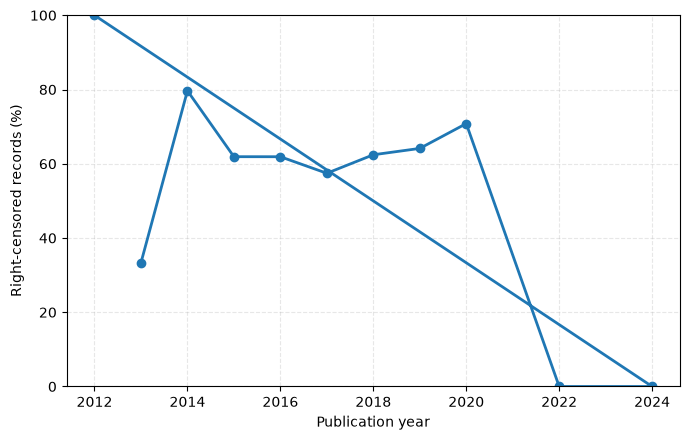

In [11]:
# ============================================================
# CELL 11 — CENSORING FRACTION BY PUBLICATION YEAR
# ============================================================

obs_year = (
    observed_surv
    .groupby("publication_year")
    .size()
    .rename("observed_T80")
)

cen_year = (
    censored_surv
    .groupby("publication_year")
    .size()
    .rename("right_censored")
)

year_table = pd.concat(
    [obs_year, cen_year],
    axis=1
).fillna(0)

year_table["total"] = (
    year_table["observed_T80"]
    + year_table["right_censored"]
)

year_table["censored_fraction"] = (
    year_table["right_censored"]
    / year_table["total"]
)

display(year_table)

# Plot
plt.figure(figsize=(7, 4.5))

plt.plot(
    year_table.index,
    100 * year_table["censored_fraction"],
    marker="o",
    linewidth=2
)

plt.xlabel("Publication year")
plt.ylabel("Right-censored records (%)")
plt.ylim(0, 100)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        WORK_DIR,
        "artifacts",
        "01_labels",
        "right_censoring_by_year.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# CELL 12 — PROTOCOL DISTRIBUTION
# ============================================================

def protocol_family(x):
    x = str(x).upper()

    if "ISOS-D" in x:
        return "ISOS-D"
    elif "ISOS-L" in x:
        return "ISOS-L"
    elif "ISOS-O" in x:
        return "ISOS-O"
    elif "ISOS-T" in x:
        return "ISOS-T"
    elif "ISOS" in x:
        return "Other ISOS"
    else:
        return "Other / unknown"

observed_surv["protocol_family"] = (
    observed_surv["Stability_protocol"]
    .apply(protocol_family)
)

censored_surv["protocol_family"] = (
    censored_surv["Stability_protocol"]
    .apply(protocol_family)
)

protocol_compare = pd.DataFrame({
    "Observed_T80": observed_surv["protocol_family"].value_counts(),
    "Right_censored": censored_surv["protocol_family"].value_counts()
}).fillna(0).astype(int)

protocol_compare["Censored_fraction"] = (
    protocol_compare["Right_censored"]
    /
    (
        protocol_compare["Observed_T80"]
        + protocol_compare["Right_censored"]
    )
)

display(protocol_compare)

,Observed_T80,Right_censored,Censored_fraction
protocol_family,,,
ISOS-D,1261,2356,0.651369
ISOS-L,492,660,0.572917
ISOS-O,0,2,1.000000
ISOS-T,2,1,0.333333
Other / unknown,60,48,0.444444
Other ISOS,20,26,0.565217


In [13]:
# ============================================================
# CELL 13 — FINAL RIGHT-CENSORING SUMMARY
# ============================================================

n_observed = len(observed_surv)
n_censored = len(censored_surv)
n_total = n_observed + n_censored

summary_censoring = pd.DataFrame({
    "Category": [
        "Observed T80",
        "Right-censored T80",
        "Combined usable stability outcomes"
    ],
    "Devices": [
        n_observed,
        n_censored,
        n_total
    ],
    "DOI_groups": [
        observed_surv["Ref_DOI_number"].nunique(),
        censored_surv["Ref_DOI_number"].nunique(),
        pd.concat([
            observed_surv["Ref_DOI_number"],
            censored_surv["Ref_DOI_number"]
        ]).nunique()
    ]
})

summary_censoring["Fraction_percent"] = [
    100 * n_observed / n_total,
    100 * n_censored / n_total,
    100.0
]

display(summary_censoring)

print(
    "\nOverall conservative censoring fraction:",
    f"{100*n_censored/n_total:.1f}%"
)

print(
    "Median censored follow-up:",
    f"{censored_surv['time_h'].median():.0f} h"
)

print(
    "75th percentile censored follow-up:",
    f"{censored_surv['time_h'].quantile(0.75):.0f} h"
)

,Category,Devices,DOI_groups,Fraction_percent
0,Observed T80,1835,964,37.236201
1,Right-censored T80,3093,1849,62.763799
2,Combined usable stability outcomes,4928,2335,100.000000



Overall conservative censoring fraction: 62.8%
Median censored follow-up: 600 h
75th percentile censored follow-up: 1000 h
